# Model-dependent analysis 

We have some data.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import _fig_params

In [20]:
x = np.linspace(0, 10, 5)
y = np.array([2.01,  4.68,  9.56, 10.62, 15.54])
yerr = np.ones_like(y) * 1.5

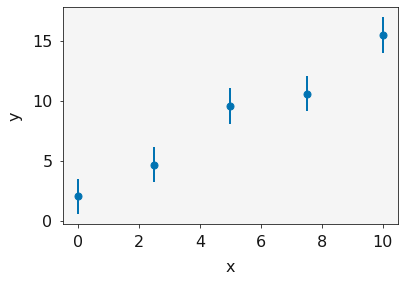

In [30]:
plt.errorbar(x, y, yerr, marker='o', ls='')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('figures/data.png', dpi=600)

We believe that $x$ and $y$ are linearly dependent, with some offset, so we *model* this with a straight line.

$$ y = m x + c $$

In [22]:
def straight_line(x, m, c):
    return m * x + c

In [23]:
popt, pcov = curve_fit(straight_line, x, y, sigma=yerr)

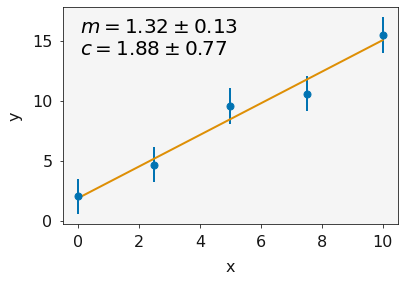

In [43]:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr, marker='o', ls='')
ax.plot(x, straight_line(x, *popt))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.05, 0.95, '$m={:.2f}\pm{:.2f}$\n$c={:.2f}\pm{:.2f}$'.format(
    popt[0], np.sqrt(pcov[0][0]), popt[1], np.sqrt(pcov[1][1])), horizontalalignment='left',
        verticalalignment='top', transform=ax.transAxes)
plt.savefig('figures/straight_line.png', dpi=600)

Where the values of the model parameters are.

In [28]:
print('m: {:.2f} +/- {:.2f}'.format(popt[0], np.sqrt(pcov[0][0])))
print('c: {:.2f} +/- {:.2f}'.format(popt[1], np.sqrt(pcov[1][1])))

m: 1.32 +/- 0.13
c: 1.88 +/- 0.77


Ofcourse, the model can be a lot more complex.